**#2026 Australian Grand Prix  ML Predictor**


(hoping verstappen wins)

In [1]:

!pip install fastf1 xgboost scikit-learn pandas numpy matplotlib seaborn requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00


In [2]:
# libraries and dependencies

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
import warnings
import os
import time

from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')
np.random.seed(42)
print(f' FastF1 version: {fastf1.__version__}')
print('All libraries loaded!')

 FastF1 version: 3.8.1
All libraries loaded!


In [14]:
# fetching real historical australlian gp results via jolpica-f1 api covers race from 2018-2025(excluding 2018 as race was cancellled)
BASE = 'https://api.jolpi.ca/ergast/f1'
AUS_YEARS = [2018, 2019, 2021, 2022, 2023, 2024, 2025]

# collecting historical race results and converting them into pandas dataframe
def fetch_aus_race_results(year):

    url = f'{BASE}/{year}/circuits/albert_park/results.json?limit=30'
    r   = requests.get(url, timeout=20)
    r.raise_for_status()
    data  = r.json()
    races = data['MRData']['RaceTable']['Races']

    if not races:
        print(f' {year}: No race data returned')
        return None

    race   = races[0]
    results = race['Results']   # list of ALL driver results

    rows = []
    for res in results:
        rows.append({
            'year':        year,
            'round':       int(race['round']),
            'driver_id':   res['Driver']['driverId'],
            'driver_name': res['Driver']['givenName'] + ' ' + res['Driver']['familyName'],
            'constructor': res['Constructor']['constructorId'],
            'grid':        int(res.get('grid', 0)),
            'finish_pos':  int(res['position']),
            'status':      res['status'],
            'points':      float(res['points']),
        })

    df = pd.DataFrame(rows)
    # Sanity check  should be ~18-20 drivers
    winner = df[df['finish_pos'] == 1]['driver_name'].values[0]
    print(f'  {year}: {len(df)} drivers | Winner: {winner}')
    return df

# now collecting qualifying results( a strong predictor )

def fetch_aus_quali_results(year):
    url = f'{BASE}/{year}/circuits/albert_park/qualifying.json?limit=30'
    r   = requests.get(url, timeout=20)
    r.raise_for_status()
    data  = r.json()
    races = data['MRData']['RaceTable']['Races']
    if not races:
        return None
    rows = []
    for res in races[0]['QualifyingResults']:
        rows.append({
            'year':      year,
            'driver_id': res['Driver']['driverId'],
            'quali_pos': int(res['position']),
        })
    return pd.DataFrame(rows)


print('Fetching Australian GP data from Jolpica-F1...')
race_frames  = []
quali_frames = []

for yr in AUS_YEARS:
    try:
        rf = fetch_aus_race_results(yr)
        qf = fetch_aus_quali_results(yr)
        if rf is not None: race_frames.append(rf)
        if qf is not None: quali_frames.append(qf)
    except Exception as e:
      print(f'  {yr}: {e}')
    time.sleep(0.4)

hist_races = pd.concat(race_frames,  ignore_index=True)
hist_quali = pd.concat(quali_frames, ignore_index=True)

print(f'\n Total rows: {len(hist_races)} race, {len(hist_quali)} quali')
print(f'   Unique drivers: {hist_races["driver_id"].nunique()}')
print(f'   Win rate check (should be ~1/{len(AUS_YEARS):.0f} = {1/len(AUS_YEARS):.2f}):')
print(f'   Overall win rate in dataset: {(hist_races["finish_pos"]==1).mean():.3f}')





Fetching Australian GP data from Jolpica-F1...
  2018: 20 drivers | Winner: Sebastian Vettel
  2019: 20 drivers | Winner: Valtteri Bottas
 2021: No race data returned
  2022: 20 drivers | Winner: Charles Leclerc
  2023: 20 drivers | Winner: Max Verstappen
  2024: 19 drivers | Winner: Carlos Sainz
  2025: 20 drivers | Winner: Lando Norris

 Total rows: 119 race, 119 quali
   Unique drivers: 39
   Win rate check (should be ~1/7 = 0.14):
   Overall win rate in dataset: 0.050


In [15]:
# now fetching full season race results to compute driver and contructor form scores(all circuits noty  just melorne)

def fetch_season_results(year):
    """Fetch all race results for a full season."""
    url = f'{BASE}/{year}/results.json?limit=1000'
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()
    rows = []
    for race in data['MRData']['RaceTable']['Races']:
        rnd = int(race['round'])
        for res in race['Results']:
            rows.append({
                'year':        year,
                'round':       rnd,
                'driver_id':   res['Driver']['driverId'],
                'constructor': res['Constructor']['constructorId'],
                'grid':        int(res.get('grid', 0)),
                'finish_pos':  int(res['position']),
                'points':      float(res['points']),
                'status':      res['status'],
            })
    return pd.DataFrame(rows)

print('Fetching full-season results 2022–2025 (for form scores)...')
season_frames = []
for yr in [2022, 2023, 2024, 2025]:
    try:
        sf = fetch_season_results(yr)
        season_frames.append(sf)
        print(f'  {yr}: {len(sf)} rows')
    except Exception as e:
        print(f'   {yr}: {e}')
    time.sleep(0.5)
all_seasons = pd.concat(season_frames, ignore_index=True)
print(f'\n Total season rows: {len(all_seasons)}')


Fetching full-season results 2022–2025 (for form scores)...
  2022: 100 rows
  2023: 100 rows
  2024: 100 rows
  2025: 100 rows

 Total season rows: 400


In [23]:
# compute driver and constructor stats from real data

print(' DATA INTEGRITY CHECK ')
print(f'Races per year:')
print(hist_races.groupby('year')['driver_id'].count().to_string())
print(f'\nDrivers with finish_pos == 1 (should be 1 per year):')
print(hist_races[hist_races['finish_pos']==1][['year','driver_name']].to_string(index=False))

# 1 melborne specific driver stats

melb_stats = hist_races.groupby('driver_id').agg(
    melb_races    = ('year',       'count'),
    melb_wins     = ('finish_pos', lambda x: (x == 1).sum()),
    melb_podiums  = ('finish_pos', lambda x: (x <= 3).sum()),
    melb_avg_pos  = ('finish_pos', 'mean'),
    melb_points   = ('points',     'sum'),
    melb_dnf_rate = ('status',     lambda x: (~x.str.startswith('Finished')
                                              & ~x.str.contains('Lap')).mean()),
).reset_index()

melb_stats['melb_win_rate']    = melb_stats['melb_wins']    / melb_stats['melb_races']
melb_stats['melb_podium_rate'] = melb_stats['melb_podiums'] / melb_stats['melb_races']

print('\n=== MELBOURNE DRIVER STATS (should NOT all be 1.0) ===')
print(melb_stats[['driver_id','melb_races','melb_wins','melb_podiums','melb_win_rate']]
      .sort_values('melb_podiums', ascending=False).head(12).to_string(index=False))

 DATA INTEGRITY CHECK 
Races per year:
year
2018    20
2019    20
2022    20
2023    20
2024    19
2025    20

Drivers with finish_pos == 1 (should be 1 per year):
 year      driver_name
 2018 Sebastian Vettel
 2019  Valtteri Bottas
 2022  Charles Leclerc
 2023   Max Verstappen
 2024     Carlos Sainz
 2025     Lando Norris

=== MELBOURNE DRIVER STATS (should NOT all be 1.0) ===
     driver_id  melb_races  melb_wins  melb_podiums  melb_win_rate
      hamilton           6          0             3       0.000000
max_verstappen           6          1             3       0.166667
       leclerc           6          1             2       0.166667
        norris           5          1             2       0.200000
       russell           5          0             2       0.000000
        bottas           5          1             1       0.200000
        alonso           5          0             1       0.000000
         sainz           6          1             1       0.166667
     raikkonen  

In [18]:
# 2 recent form : last 2 seasons(2024+2025)

recent = all_seasons[all_seasons['year'] >= 2024].copy()
driver_form = recent.groupby('driver_id').agg(
    recent_wins        = ('finish_pos', lambda x: (x == 1).sum()),
    recent_podiums     = ('finish_pos', lambda x: (x <= 3).sum()),
    recent_points      = ('points',     'sum'),
    recent_races       = ('round',      'count'),
    recent_avg_pos     = ('finish_pos', 'mean'),
    recent_dnf_rate    = ('status',     lambda x: (~x.str.startswith('Finished')
                                                   & ~x.str.contains('Lap')).mean()),
).reset_index()
driver_form['recent_win_rate']     = driver_form['recent_wins'] / driver_form['recent_races'].clip(lower=1)
driver_form['recent_pts_per_race'] = driver_form['recent_points'] / driver_form['recent_races'].clip(lower=1)

In [19]:
# 3 constructor form : 2025 season
con_2025 = all_seasons[all_seasons['year'] == 2025]
constructor_form = con_2025.groupby('constructor').agg(
    con_wins        = ('finish_pos', lambda x: (x == 1).sum()),
    con_podiums     = ('finish_pos', lambda x: (x <= 3).sum()),
    con_points      = ('points',     'sum'),
    con_races       = ('round',      'count'),
).reset_index()
constructor_form['con_pts_per_race'] = constructor_form['con_points'] / constructor_form['con_races'].clip(lower=1)

print('\n Stats computed correctly!')



 Stats computed correctly!


In [20]:
print('Driver Melbourne stats:')
print(melb_stats[['driver_id','melb_races','melb_wins','melb_podiums','melb_win_rate']]
      .sort_values('melb_podiums', ascending=False).head(10).to_string(index=False))

Driver Melbourne stats:
     driver_id  melb_races  melb_wins  melb_podiums  melb_win_rate
      hamilton           6          0             3       0.000000
max_verstappen           6          1             3       0.166667
       leclerc           6          1             2       0.166667
        norris           5          1             2       0.200000
       russell           5          0             2       0.000000
        bottas           5          1             1       0.200000
        alonso           5          0             1       0.000000
         sainz           6          1             1       0.166667
     raikkonen           2          0             1       0.000000
         perez           5          0             1       0.000000


In [27]:
# building ml training dataset
# each row = one driver in aus gp
# label= did they win (1/0)
training=hist_races.merge(
    hist_quali[['year', 'driver_id','quali_pos']],
    on=['year','driver_id'], how='left'
)

# grid features (using exponential decay)
training['grid_advantage']=np.exp(-0.15*(training['grid'].clip(lower=1)-1))
training['quali_advantage'] = np.exp(-0.15 * (training['quali_pos'].fillna(training['grid']).clip(lower=1) - 1))


# merge stats
training = training.merge(melb_stats,       on='driver_id',   how='left')
training = training.merge(driver_form,      on='driver_id',   how='left')
training = training.merge(constructor_form, on='constructor', how='left')

# creating target variable (win label)
training['won'] = (training['finish_pos']==1).astype(int)

# fill nans
fill_zero = ['melb_wins','melb_podiums','melb_win_rate','melb_podium_rate',
             'melb_dnf_rate','recent_wins','recent_podiums','recent_win_rate',
             'recent_pts_per_race','recent_dnf_rate','con_pts_per_race']
for col in fill_zero:
    if col in training.columns:
        training[col] = training[col].fillna(0)
training['melb_avg_pos']    = training['melb_avg_pos'].fillna(15)
training['recent_avg_pos']  = training['recent_avg_pos'].fillna(15)


# defining feature list
FEATURES = [
    'grid_advantage',
    'quali_advantage',
    'melb_win_rate',
    'melb_podium_rate',
    'melb_avg_pos',
    'melb_dnf_rate',
    'recent_win_rate',
    'recent_pts_per_race',
    'recent_avg_pos',
    'recent_dnf_rate',
    'con_pts_per_race',
]

X = training[FEATURES].values
y = training['won'].values

print(f'Training set: {len(X)} rows')
print(f'Wins in dataset: {y.sum()} / {len(y)} = {y.mean():.3f} (should be ~0.05)')
print(f'Features: {FEATURES}')


Training set: 119 rows
Wins in dataset: 6 / 119 = 0.050 (should be ~0.05)
Features: ['grid_advantage', 'quali_advantage', 'melb_win_rate', 'melb_podium_rate', 'melb_avg_pos', 'melb_dnf_rate', 'recent_win_rate', 'recent_pts_per_race', 'recent_avg_pos', 'recent_dnf_rate', 'con_pts_per_race']


In [28]:
# train and compare models

cv =StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models={
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, verbosity=0),
    'Gradient-Boost': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'Logistic Regression':Pipeline([
                          ('scaler', StandardScaler()),
                          ('clf',    LogisticRegression(C=1.0, max_iter=1000, random_state=42))
                      ]),
}

print('Croos validation ROC_AUC[5-fold]:')
for name, model in models.items():
  score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
  print(f'{name:<20}{score.mean():.4f} ± {score.std():.4f}')

best_model = models['XGBoost']
best_model.fit(X, y)
print('\n XGBoost trained on full dataset.')

Croos validation ROC_AUC[5-fold]:
XGBoost             0.9735 ± 0.0216
Gradient-Boost      0.7390 ± 0.3820
Random Forest       0.9103 ± 0.1155
Logistic Regression 0.9781 ± 0.0194

 XGBoost trained on full dataset.


In [29]:
# build 2026 grid feature vectors
grid_2026 = [
    ('russell',        'George Russell',    'mercedes',    1),
    ('antonelli',      'Kimi Antonelli',    'mercedes',    2),
    ('hadjar',         'Isack Hadjar',      'red_bull',    3),
    ('leclerc',        'Charles Leclerc',   'ferrari',     4),
    ('piastri',        'Oscar Piastri',     'mclaren',     5),
    ('norris',         'Lando Norris',      'mclaren',     6),
    ('hamilton',       'Lewis Hamilton',    'ferrari',     7),
    ('lawson',         'Liam Lawson',       'rb',          8),
    ('lindblad',       'Arvid Lindblad',    'rb',          9),
    ('bortoleto',      'Gabriel Bortoleto', 'sauber',     10),
    ('hulkenberg',     'Nico Hulkenberg',   'sauber',     11),
    ('bearman',        'Oliver Bearman',    'haas',       12),
    ('ocon',           'Esteban Ocon',      'haas',       13),
    ('gasly',          'Pierre Gasly',      'alpine',     14),
    ('albon',          'Alex Albon',        'williams',   15),
    ('colapinto',      'Franco Colapinto',  'alpine',     16),
    ('alonso',         'Fernando Alonso',   'aston_martin',17),
    ('perez',          'Sergio Perez',      'cadillac',   18),
    ('bottas',         'Valtteri Bottas',   'cadillac',   19),
    ('max_verstappen', 'Max Verstappen',    'red_bull',   20),
    ('sainz',          'Carlos Sainz',      'williams',   21),
    ('stroll',         'Lance Stroll',      'aston_martin',22),
]

df_2026 = pd.DataFrame(grid_2026, columns=['driver_id','driver_name','constructor','grid_pos'])
df_2026['grid_advantage']  = np.exp(-0.15 * (df_2026['grid_pos'] - 1))
df_2026['quali_advantage'] = df_2026['grid_advantage']  # same as grid for 2026


# Merge historical stats
df_2026 = df_2026.merge(melb_stats[['driver_id','melb_win_rate','melb_podium_rate',
                                     'melb_avg_pos','melb_dnf_rate']],
                         on='driver_id', how='left')
df_2026 = df_2026.merge(driver_form[['driver_id','recent_win_rate','recent_pts_per_race',
                                      'recent_avg_pos','recent_dnf_rate']],
                         on='driver_id', how='left')

# 2026 constructor pace (scaled from 2025 base + 2026 quali evidence)
perf_2026 = {
    'mercedes': 1.40, 'mclaren': 1.10, 'ferrari': 1.05,
    'red_bull': 0.90, 'rb': 0.70, 'sauber': 0.55,
    'haas': 0.50, 'alpine': 0.48, 'williams': 0.45,
    'aston_martin': 0.40, 'cadillac': 0.30,
}
df_2026['con_pts_per_race'] = df_2026['constructor'].map(perf_2026).fillna(0.30)
# Fill rookies / newcomers
df_2026['melb_win_rate']       = df_2026['melb_win_rate'].fillna(0.0)
df_2026['melb_podium_rate']    = df_2026['melb_podium_rate'].fillna(0.0)
df_2026['melb_avg_pos']        = df_2026['melb_avg_pos'].fillna(14.0)
df_2026['melb_dnf_rate']       = df_2026['melb_dnf_rate'].fillna(0.15)
df_2026['recent_win_rate']     = df_2026['recent_win_rate'].fillna(0.0)
df_2026['recent_pts_per_race'] = df_2026['recent_pts_per_race'].fillna(3.0)
df_2026['recent_avg_pos']      = df_2026['recent_avg_pos'].fillna(14.0)
df_2026['recent_dnf_rate']     = df_2026['recent_dnf_rate'].fillna(0.15)

print(df_2026[['driver_name','grid_pos','melb_win_rate','recent_win_rate',
               'con_pts_per_race']].to_string(index=False))

      driver_name  grid_pos  melb_win_rate  recent_win_rate  con_pts_per_race
   George Russell         1       0.000000         0.000000              1.40
   Kimi Antonelli         2       0.000000         0.000000              1.40
     Isack Hadjar         3       0.000000         0.000000              0.90
  Charles Leclerc         4       0.166667         0.000000              1.05
    Oscar Piastri         5       0.000000         0.300000              1.10
     Lando Norris         6       0.200000         0.181818              1.10
   Lewis Hamilton         7       0.000000         0.000000              1.05
      Liam Lawson         8       0.000000         0.000000              0.70
   Arvid Lindblad         9       0.000000         0.000000              0.70
Gabriel Bortoleto        10       0.000000         0.000000              0.55
  Nico Hulkenberg        11       0.000000         0.000000              0.55
   Oliver Bearman        12       0.000000         0.000000     

In [30]:
# predict and siplay win probabilities

X_2026 = df_2026[FEATURES].values
raw_probs=best_model.predict_proba(X_2026)[:,1]

df_2026['win_prob']=raw_probs/raw_probs.sum()
df_2026['win_prob_pct'] = (df_2026['win_prob'] * 100).round(2)
pred = df_2026[['driver_name','constructor','grid_pos','win_prob_pct']]\
         .sort_values('win_prob_pct', ascending=False).reset_index(drop=True)
print('\n 2026 AUSTRALIAN GP —XGBoost Win Probability')

for i, row in pred.iterrows():
    bar  = '█' * int(row['win_prob_pct'] / 1.5)
    tag  = ' ← FAVOURITE' if i == 0 else ''
    print(f"  P{row['grid_pos']:>2}  {row['driver_name']:<22}  {row['win_prob_pct']:>5.1f}%  {bar}{tag}")


 2026 AUSTRALIAN GP —XGBoost Win Probability
  P 1  George Russell           37.1%  ████████████████████████ ← FAVOURITE
  P 2  Kimi Antonelli           35.8%  ███████████████████████
  P19  Valtteri Bottas           6.7%  ████
  P 3  Isack Hadjar              6.3%  ████
  P 4  Charles Leclerc           2.9%  █
  P 6  Lando Norris              2.7%  █
  P21  Carlos Sainz              2.2%  █
  P20  Max Verstappen            0.6%  
  P10  Gabriel Bortoleto         0.5%  
  P 8  Liam Lawson               0.5%  
  P 5  Oscar Piastri             0.5%  
  P14  Pierre Gasly              0.5%  
  P13  Esteban Ocon              0.4%  
  P 9  Arvid Lindblad            0.4%  
  P16  Franco Colapinto          0.4%  
  P18  Sergio Perez              0.4%  
  P12  Oliver Bearman            0.4%  
  P11  Nico Hulkenberg           0.4%  
  P22  Lance Stroll              0.4%  
  P17  Fernando Alonso           0.4%  
  P15  Alex Albon                0.4%  
  P 7  Lewis Hamilton            0.1%  


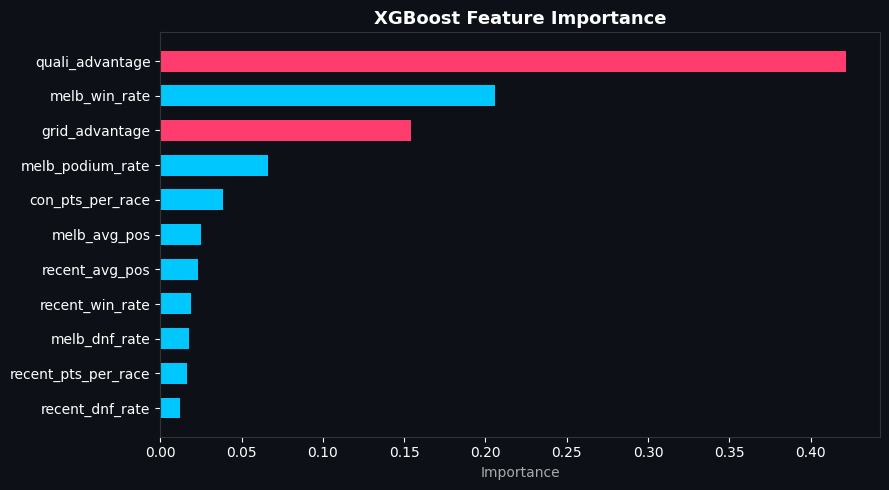

In [32]:
# visualization of feature importance

feat_imp = pd.DataFrame({'feature': FEATURES,
                          'importance': best_model.feature_importances_})\
             .sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
bar_colors = ['#ff3c6e' if 'grid' in f or 'quali' in f else '#00c8ff'
              for f in feat_imp['feature']]
ax.barh(feat_imp['feature'], feat_imp['importance'],
        color=bar_colors, edgecolor='none', height=0.6)
ax.set_title('XGBoost Feature Importance', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.set_xlabel('Importance', color='#aaa')
for sp in ax.spines.values(): sp.set_color('#333')
plt.tight_layout()
plt.savefig('feature_importance_2026.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [39]:
# lets add a simulation layer also
# monte carlo simulation(around 15K)
# Real DNF rates + Albert Park SC rate

N=15_000

# initialize win counter
win_counts = {d: 0 for d in df_2026['driver_name']}
# extract base probs
base_probs=df_2026.set_index('driver_name')['win_prob'].to_dict()

# load driver dnf rates
dnf_rates = df_2026.set_index('driver_name')['recent_dnf_rate'].to_dict()


# store grid positions
grid_pos = df_2026.set_index('driver_name')['grid_pos'].to_dict()


# define race chaos parameters
SC_PROB        = 0.65  # Albert Park historical SC rate
NEW_REGS_CHAOS = 0.15  # first race of new regulations

# starting simulation loop
for _ in range(N):
  # creating probability vector
  drivers=list(base_probs.keys())
  probs=np.array([base_probs[d] for d in drivers], dtype=float)
 # DNFs
  for i, d in enumerate(drivers):
      if np.random.rand() < dnf_rates.get(d, 0.12):
          probs[i] = 0.0

    # Safety car lottery
  if np.random.rand() < SC_PROB:
      for i, d in enumerate(drivers):
          if 4 <= grid_pos.get(d, 20) <= 10:
              probs[i] *= np.random.uniform(1.3, 2.0)

    # New regs chaos
  if np.random.rand() < NEW_REGS_CHAOS:
      lucky = np.random.randint(3, 12)
      probs[lucky] *= np.random.uniform(1.5, 3.0)

  if probs.sum() == 0: continue
  probs /= probs.sum()
  win_counts[np.random.choice(drivers, p=probs)] += 1

sim_df = pd.DataFrame([
    {'driver_name': d,
     'grid_pos': grid_pos.get(d,99),
     'sim_pct':  win_counts[d] / N * 100}
    for d in win_counts
]).sort_values('sim_pct', ascending=False).reset_index(drop=True)


print(f' MONTE CARLO ({N:,} sims):')
for _, r in sim_df.head(8).iterrows():
    bar = '█' * int(r['sim_pct']/1.2)
    print(f"  P{r['grid_pos']:>2}  {r['driver_name']:<22}  {r['sim_pct']:>5.1f}%  {bar}")


 MONTE CARLO (15,000 sims):
  P 2  Kimi Antonelli           38.3%  ███████████████████████████████
  P 1  George Russell           33.4%  ███████████████████████████
  P 3  Isack Hadjar              5.7%  ████
  P19  Valtteri Bottas           5.7%  ████
  P 4  Charles Leclerc           4.1%  ███
  P 6  Lando Norris              3.9%  ███
  P21  Carlos Sainz              1.8%  █
  P 5  Oscar Piastri             0.9%  


In [40]:
# final ensemble prediction
ml_dict  = df_2026.set_index('driver_name')['win_prob'].to_dict()
sim_dict = sim_df.set_index('driver_name')['sim_pct'].div(100).to_dict()

ensemble = {d: 0.60*ml_dict.get(d,0) + 0.40*sim_dict.get(d,0)
            for d in df_2026['driver_name']}
total    = sum(ensemble.values())
ensemble = {d: v/total for d, v in ensemble.items()}

final = pd.DataFrame([
    {'driver':     d,
     'team':       df_2026[df_2026['driver_name']==d]['constructor'].values[0],
     'grid':       int(grid_pos.get(d,99)),
     'ml_pct':     round(ml_dict.get(d,0)*100, 1),
     'sim_pct':    round(sim_dict.get(d,0)*100, 1),
     'final_pct':  round(v*100, 1)}
    for d, v in ensemble.items()
]).sort_values('final_pct', ascending=False).reset_index(drop=True)


In [42]:
print('  2026 AUSTRALIAN GRAND PRIX — FINAL PREDICTION')
print('  Data: Jolpica API + XGBoost model + Monte Carlo simulation')

print(f"  {'Grid':<6}{'Driver':<22}{'XGB':>8}{'Sim':>8}{'Final':>10}")


for i, row in final.head(8).iterrows():
    rank = i + 1
    print(f"  {rank:<2} P{row['grid']:<3} "
          f"{row['driver']:<22} "
          f"{row['ml_pct']:>6.1f}% "
          f"{row['sim_pct']:>6.1f}% "
          f"{row['final_pct']:>8.1f}%")

winner = final.iloc[0]

print()

print(f"Predicted winner: {winner['driver']}")
print(f"Team: {winner['team'].replace('_',' ').title()}")
print(f"Starting position: P{winner['grid']}")
print(f"Estimated win probability: {winner['final_pct']:.1f}%")


  2026 AUSTRALIAN GRAND PRIX — FINAL PREDICTION
  Data: Jolpica API + XGBoost model + Monte Carlo simulation
  Grid  Driver                     XGB     Sim     Final
  1  P2   Kimi Antonelli           35.8%   38.3%     36.8%
  2  P1   George Russell           37.1%   33.4%     35.6%
  3  P19  Valtteri Bottas           6.7%    5.7%      6.3%
  4  P3   Isack Hadjar              6.3%    5.7%      6.1%
  5  P4   Charles Leclerc           2.9%    4.1%      3.4%
  6  P6   Lando Norris              2.7%    3.9%      3.2%
  7  P21  Carlos Sainz              2.2%    1.8%      2.0%
  8  P5   Oscar Piastri             0.5%    0.9%      0.7%

Predicted winner: Kimi Antonelli
Team: Mercedes
Starting position: P2
Estimated win probability: 36.8%
